In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


In [2]:
from safetensors.torch import load_file

def get_lora_deltas(repo_name: str, lora_alpha: int = 32, r: int = 16) -> dict:
    """Compute ΔW = lora_B @ lora_A * (alpha/r) directly from adapter weights."""
    from huggingface_hub import hf_hub_download

    path = hf_hub_download(
        repo_id  = f"Srishtik/{repo_name}",
        filename = "adapter_model.safetensors"
    )
    adapter_weights = load_file(path)
    scale = lora_alpha / r

    # Group A and B matrices by layer
    layers = {}
    for key, val in adapter_weights.items():
        if "lora_A" in key:
            base_key = key.replace("lora_A.default.weight", "").replace("lora_A.weight", "")
            layers.setdefault(base_key, {})["A"] = val.float()
        elif "lora_B" in key:
            base_key = key.replace("lora_B.default.weight", "").replace("lora_B.weight", "")
            layers.setdefault(base_key, {})["B"] = val.float()

    # Compute ΔW for each layer
    deltas = {}
    for base_key, mats in layers.items():
        if "A" in mats and "B" in mats:
            deltas[base_key] = scale * (mats["B"] @ mats["A"])  # (d_out, d_in)

    return deltas


# ── Usage ──
deltas_1 = get_lora_deltas("qwen3-trained-on-dolly-15k")
deltas_2 = get_lora_deltas("qwen3-trained-on-code-alpaca-18k")
deltas_3=get_lora_deltas("qwen3-trained-on-metamath-15k")
print(f"Adapter 1 layers: {len(deltas_1)}")
print(f"Adapter 2 layers: {len(deltas_2)}")
print(f"Sample keys: {list(deltas_1.keys())[:3]}")

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

Adapter 1 layers: 196
Adapter 2 layers: 196
Sample keys: ['base_model.model.model.layers.0.mlp.down_proj.', 'base_model.model.model.layers.0.mlp.gate_proj.', 'base_model.model.model.layers.0.mlp.up_proj.']


In [3]:
from transformers import AutoModelForCausalLM
import torch

base_model = AutoModelForCausalLM.from_pretrained(
    "unsloth/Qwen3-0.6B",
    torch_dtype=torch.float16,
    device_map="cpu",
)
base_sd = {k: v.cpu() for k, v in base_model.state_dict().items()}
del base_model
torch.cuda.empty_cache()

print(f"Base keys: {len(base_sd)}")
print(f"Sample base keys: {list(base_sd.keys())[:3]}")


config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

Base keys: 311
Sample base keys: ['model.embed_tokens.weight', 'model.layers.0.self_attn.q_proj.weight', 'model.layers.0.self_attn.k_proj.weight']


In [4]:
from unsloth import FastLanguageModel
def get_merged_deltas(repo_name: str, base_sd: dict) -> dict:
    model, _ = FastLanguageModel.from_pretrained(
        model_name     = f"Srishtik/{repo_name}",
        max_seq_length = 1024,
        load_in_4bit   = False,
        dtype          = torch.float16,
        device_map     = "cpu",
    )
    merged_sd = {k: v.cpu() for k, v in model.state_dict().items()}
    del model
    torch.cuda.empty_cache()

    deltas = {}
    for key in merged_sd:
        if key in base_sd:
            diff = merged_sd[key].float() - base_sd[key].float()
            if diff.dim() == 2:
                deltas[key] = diff
    return deltas

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:1427: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!


In [5]:
model, _ = FastLanguageModel.from_pretrained(
    model_name = "Srishtik/Qwen3-0.6B-linear-3-adapters-merged-2",
    max_seq_length = 1024,
    load_in_4bit = False,
    dtype = torch.float16,
    device_map = "cpu",
)
merged_sd = {k: v.cpu() for k, v in model.state_dict().items()}

# Compare directly against base
key = "model.layers.0.self_attn.q_proj.weight"
diff = (merged_sd[key].float() - base_sd[key].float()).abs().max()
print(f"Max abs diff at {key}: {diff.item()}")

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Max abs diff at model.layers.0.self_attn.q_proj.weight: 0.00482177734375


In [6]:
linear_deltas=get_merged_deltas("Qwen3-0.6B-linear-3-adapters-merged-2",base_sd)

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [7]:
svd_deltas=get_merged_deltas("Qwen3-0.6B-svd-3-adapters-merged-2",base_sd)

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [8]:
ties_deltas=get_merged_deltas("Qwen3-0.6B-ties-3-adapters-merged-2",base_sd)

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [9]:
dare_deltas=get_merged_deltas("Qwen3-0.6B-dare-3-adapters-merged-2",base_sd)

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [10]:
slerp_deltas=get_merged_deltas("Qwen3-0.6B-slerp-3-adapters-merged-2",base_sd)

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [11]:
!git clone https://github.com/SrishtikSekar/Lora_Adapter_Merging.git

Cloning into 'Lora_Adapter_Merging'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 175 (delta 97), reused 112 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 13.22 MiB | 22.48 MiB/s, done.
Resolving deltas: 100% (97/97), done.


In [12]:
!ls

huggingface_tokenizers_cache  Lora_Adapter_Merging  unsloth_compiled_cache


In [13]:
%cd Lora_Adapter_Merging

/kaggle/working/Lora_Adapter_Merging


In [14]:
from frobenius_norm import frobenius_norm

In [15]:
len(linear_deltas)

198

## Deleting Keys

In the context of Large Language Models (LLMs), model.embed_tokens.weight and lm_head.weight appear as "extra" or separate layers because they sit outside the core Transformer backbone. They act as the entry and exit gates for text processing
So we delete them


In [16]:
def delete_keys(deltas):
    for key in list(deltas.keys()):
        if key=="lm_head.weight" or key=="model.embed_tokens.weight":
            deltas.pop(key)


In [17]:
delete_keys(linear_deltas)
delete_keys(svd_deltas)
delete_keys(ties_deltas)
delete_keys(dare_deltas)
delete_keys(slerp_deltas)

## Frobenius Norm

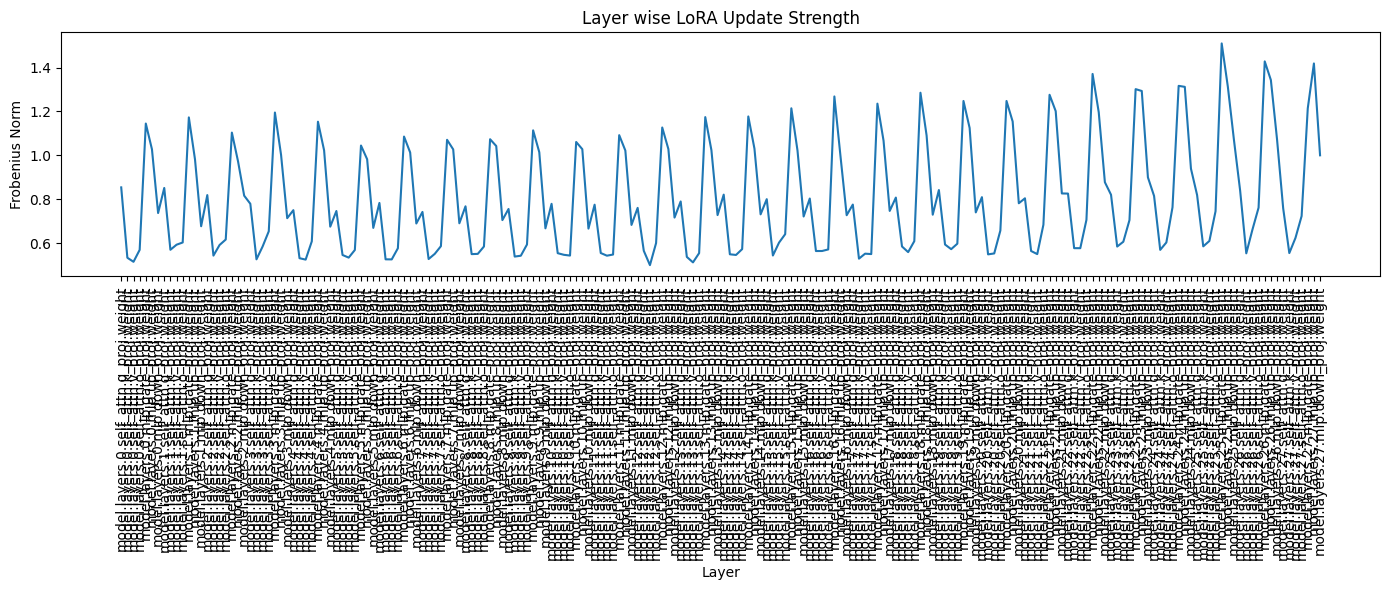

In [18]:
frobenius_norm(linear_deltas)

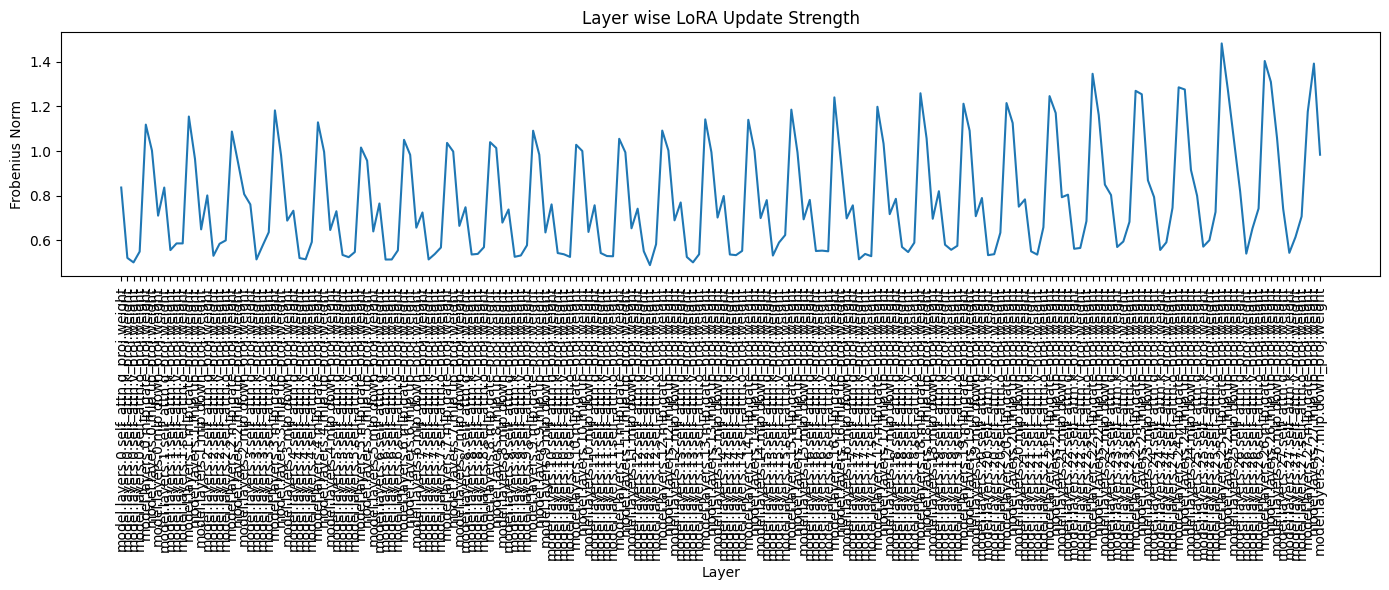

In [19]:
frobenius_norm(svd_deltas)

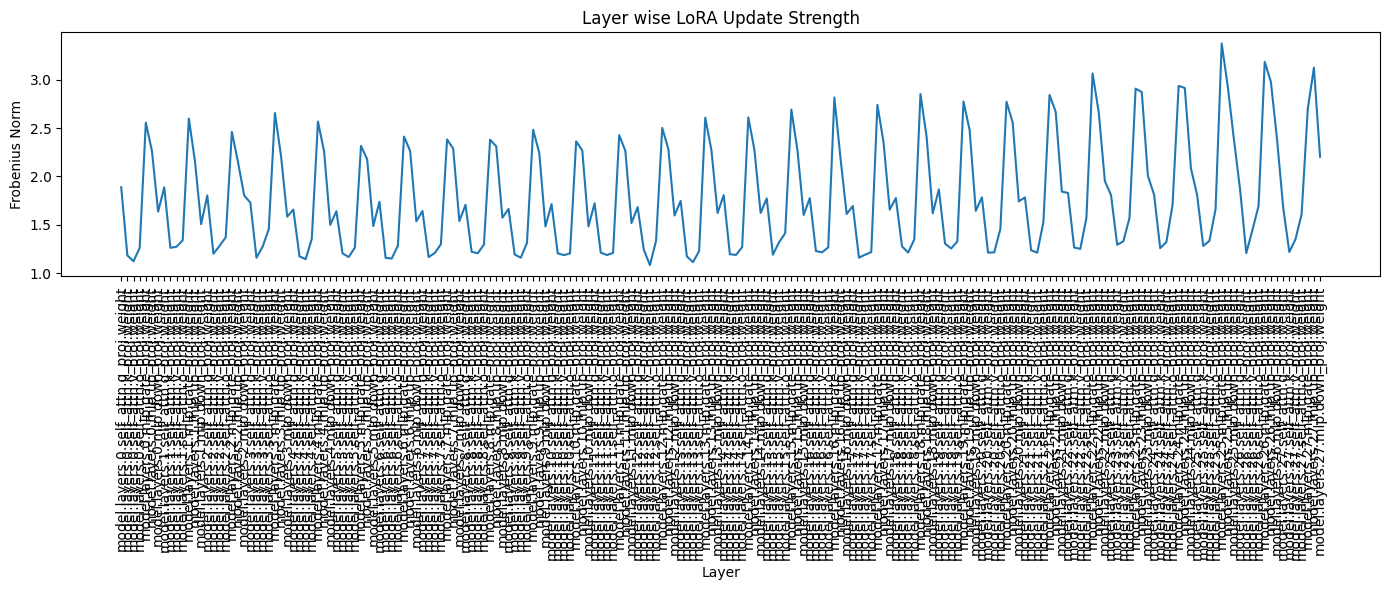

In [20]:
frobenius_norm(dare_deltas)

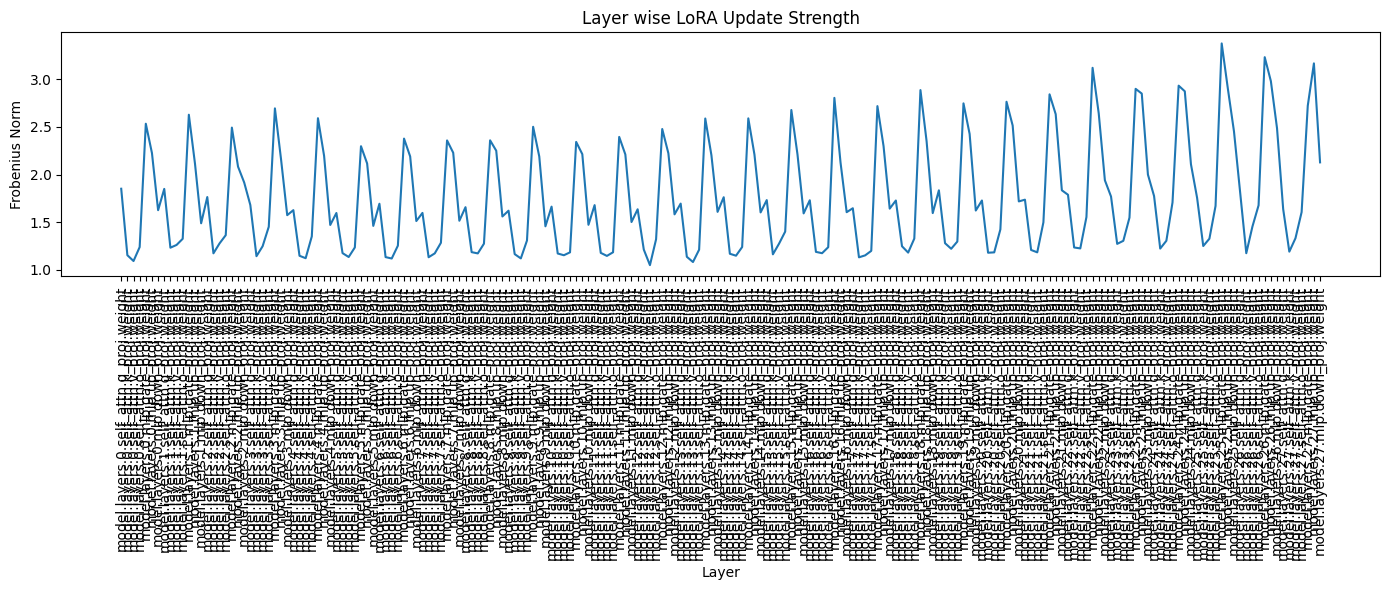

In [21]:
frobenius_norm(ties_deltas)

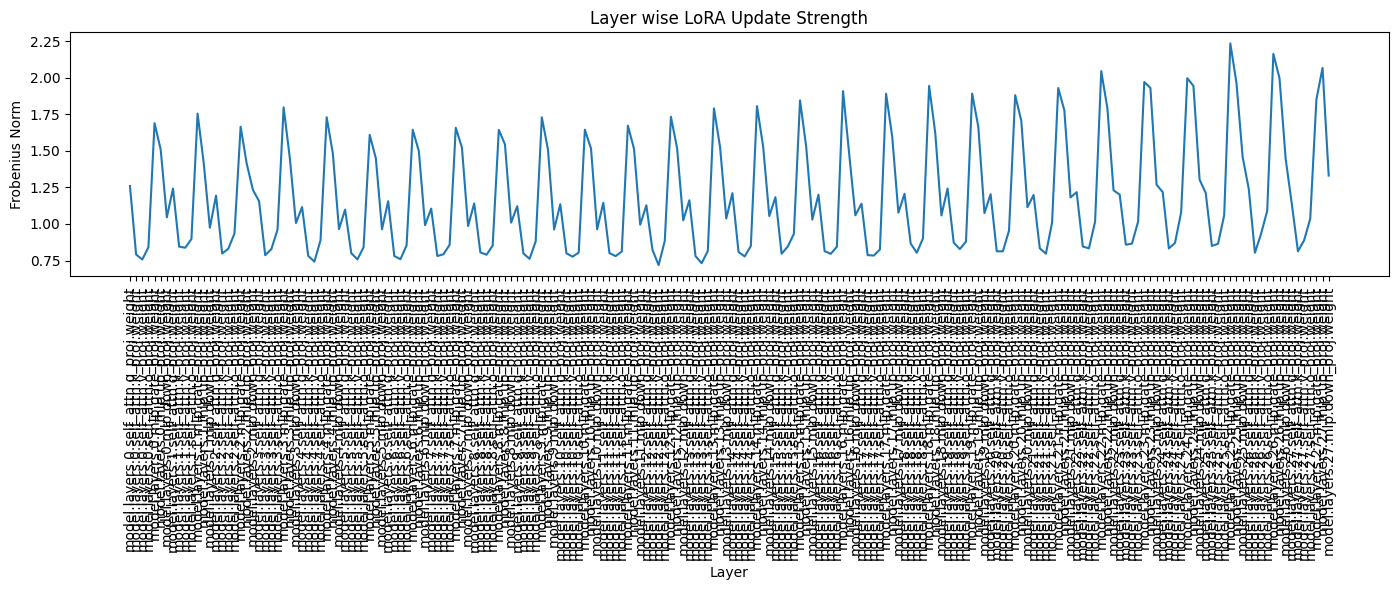

In [22]:
frobenius_norm(slerp_deltas)

## Singular Values

In [23]:

import numpy as np
import torch
import matplotlib.pyplot as plt
def singular_values(deltas):
    layer_name=list(deltas.keys())[30]
    svals1 = torch.linalg.svdvals(deltas[layer_name]).cpu().numpy()
    plt.figure(figsize=(10, 5))
    plt.plot(svals1)
    plt.xlabel("Singular Value Index")
    plt.ylabel("Magnitude")
    plt.title(f"Singular Spectrum: {layer_name}")
    plt.show()


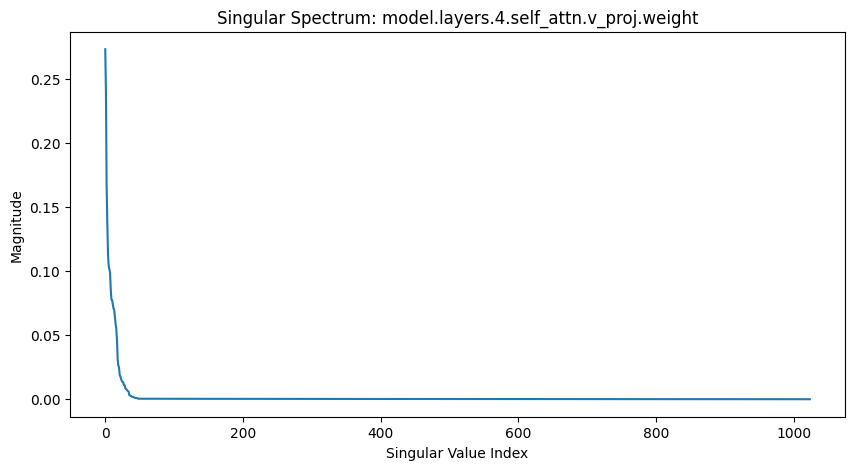

In [24]:
singular_values(linear_deltas)